In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/content/Asthma_dataset.csv')

In [5]:
df.head(10)

,Patient_ID,Age,Gender,BMI,Smoking Status,Family History,Allergies,Air Pollution Level,Physical Activity Level,Occupation Type,Comorbidities,Medication Adherence,Number of ER Visits,Peak Expiratory Flow,FeNO Level,Has Asthma,Asthma_Control_Level
0,ASTH100009,88,Male,15.0,Current,1,0,Low,Active,Indoor,0,0.36,3,377.0,14.9,0,NaN
1,ASTH100017,38,Male,15.0,Current,0,0,Moderate,Moderate,Outdoor,Diabetes,0.25,1,429.1,10.9,0,NaN
2,ASTH100097,65,Male,19.9,Current,0,0,Low,Sedentary,Indoor,0,0.86,0,430.9,26.8,0,NaN
3,ASTH100144,52,Female,28.4,Current,0,0,Moderate,Sedentary,Indoor,0,0.28,0,600.0,17.3,0,NaN
4,ASTH100188,32,Female,27.3,Current,0,0,Moderate,Sedentary,Indoor,0,0.60,1,324.2,28.1,0,NaN
5,ASTH100196,2,Female,33.7,Current,0,0,Low,Active,Indoor,Both,0.68,0,379.8,20.5,0,NaN
6,ASTH100203,54,Male,19.9,Current,1,0,Low,Moderate,Indoor,Both,0.39,1,259.0,21.9,0,NaN
7,ASTH100235,19,Female,23.1,Current,0,0,Moderate,Sedentary,Indoor,Hypertension,0.52,0,600.0,41.8,0,NaN
8,ASTH100236,20,Female,28.6,Current,1,0,Low,Moderate,Indoor,0,0.48,1,408.9,30.3,0,NaN
9,ASTH100300,59,Male,26.2,Current,0,0,Moderate,Moderate,Indoor,Diabetes,0.43,1,488.1,32.0,0,NaN


In [6]:
data = df.drop(columns = ['Patient_ID','Asthma_Control_Level'])

In [7]:
data['Gender'] = data['Gender'].map({'Male':0,'Female':1,'Other':2})
data['Smoking Status'] = data['Smoking Status'].map({'Never':0,'Former':1,'Current':2})
data['Allergies'] = data['Allergies'].map({'0':0,'Dust':1,'Pets':2,'Pollen':3,'Multiple':4})
data['Air Pollution Level'] = data['Air Pollution Level'].map({'Low':0,'Moderate':1,'High':2})
data['Physical Activity Level'] = data['Physical Activity Level'].map({'Active':0,'Moderate':1,'Sedentary':2})
data['Occupation Type'] = data['Occupation Type'].map({'Indoor':0,'Outdoor':1})
data['Comorbidities'] = data['Comorbidities'].map({'0':0,'Diabetes':1,'Hypertension':2,'Both':3})


In [8]:
data.shape

(10000, 15)

In [9]:
data.dtypes

,0
Age,int64
Gender,int64
BMI,float64
Smoking Status,int64
Family History,int64
Allergies,int64
Air Pollution Level,int64
Physical Activity Level,int64
Occupation Type,int64
Comorbidities,int64


In [10]:
data.head(20)

,Age,Gender,BMI,Smoking Status,Family History,Allergies,Air Pollution Level,Physical Activity Level,Occupation Type,Comorbidities,Medication Adherence,Number of ER Visits,Peak Expiratory Flow,FeNO Level,Has Asthma
0,88,0,15.0,2,1,0,0,0,0,0,0.36,3,377.0,14.9,0
1,38,0,15.0,2,0,0,1,1,1,1,0.25,1,429.1,10.9,0
2,65,0,19.9,2,0,0,0,2,0,0,0.86,0,430.9,26.8,0
3,52,1,28.4,2,0,0,1,2,0,0,0.28,0,600.0,17.3,0
4,32,1,27.3,2,0,0,1,2,0,0,0.60,1,324.2,28.1,0
5,2,1,33.7,2,0,0,0,0,0,3,0.68,0,379.8,20.5,0
6,54,0,19.9,2,1,0,0,1,0,3,0.39,1,259.0,21.9,0
7,19,1,23.1,2,0,0,1,2,0,2,0.52,0,600.0,41.8,0
8,20,1,28.6,2,1,0,0,1,0,0,0.48,1,408.9,30.3,0
9,59,0,26.2,2,0,0,1,1,0,1,0.43,1,488.1,32.0,0


In [11]:
df.describe()

,Age,BMI,Family History,Medication Adherence,Number of ER Visits,Peak Expiratory Flow,FeNO Level,Has Asthma
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,44.930700,25.053320,0.303400,0.497998,1.015900,400.884090,25.101420,0.243300
std,25.653559,4.874466,0.459749,0.224809,1.020564,97.531113,9.840184,0.429096
min,1.000000,15.000000,0.000000,0.000000,0.000000,150.000000,5.000000,0.000000
25%,23.000000,21.600000,0.000000,0.320000,0.000000,334.800000,18.200000,0.000000
50%,45.000000,25.000000,0.000000,0.500000,1.000000,402.500000,25.000000,0.000000
75%,67.000000,28.400000,1.000000,0.670000,2.000000,468.700000,31.700000,0.000000
max,89.000000,45.000000,1.000000,0.990000,6.000000,600.000000,63.900000,1.000000


In [12]:
df.describe().round(2).to_csv("descriptive_statistics.csv")

In [13]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
BMI,0
Smoking Status,0
Family History,0
Allergies,0
Air Pollution Level,0
Physical Activity Level,0
Occupation Type,0


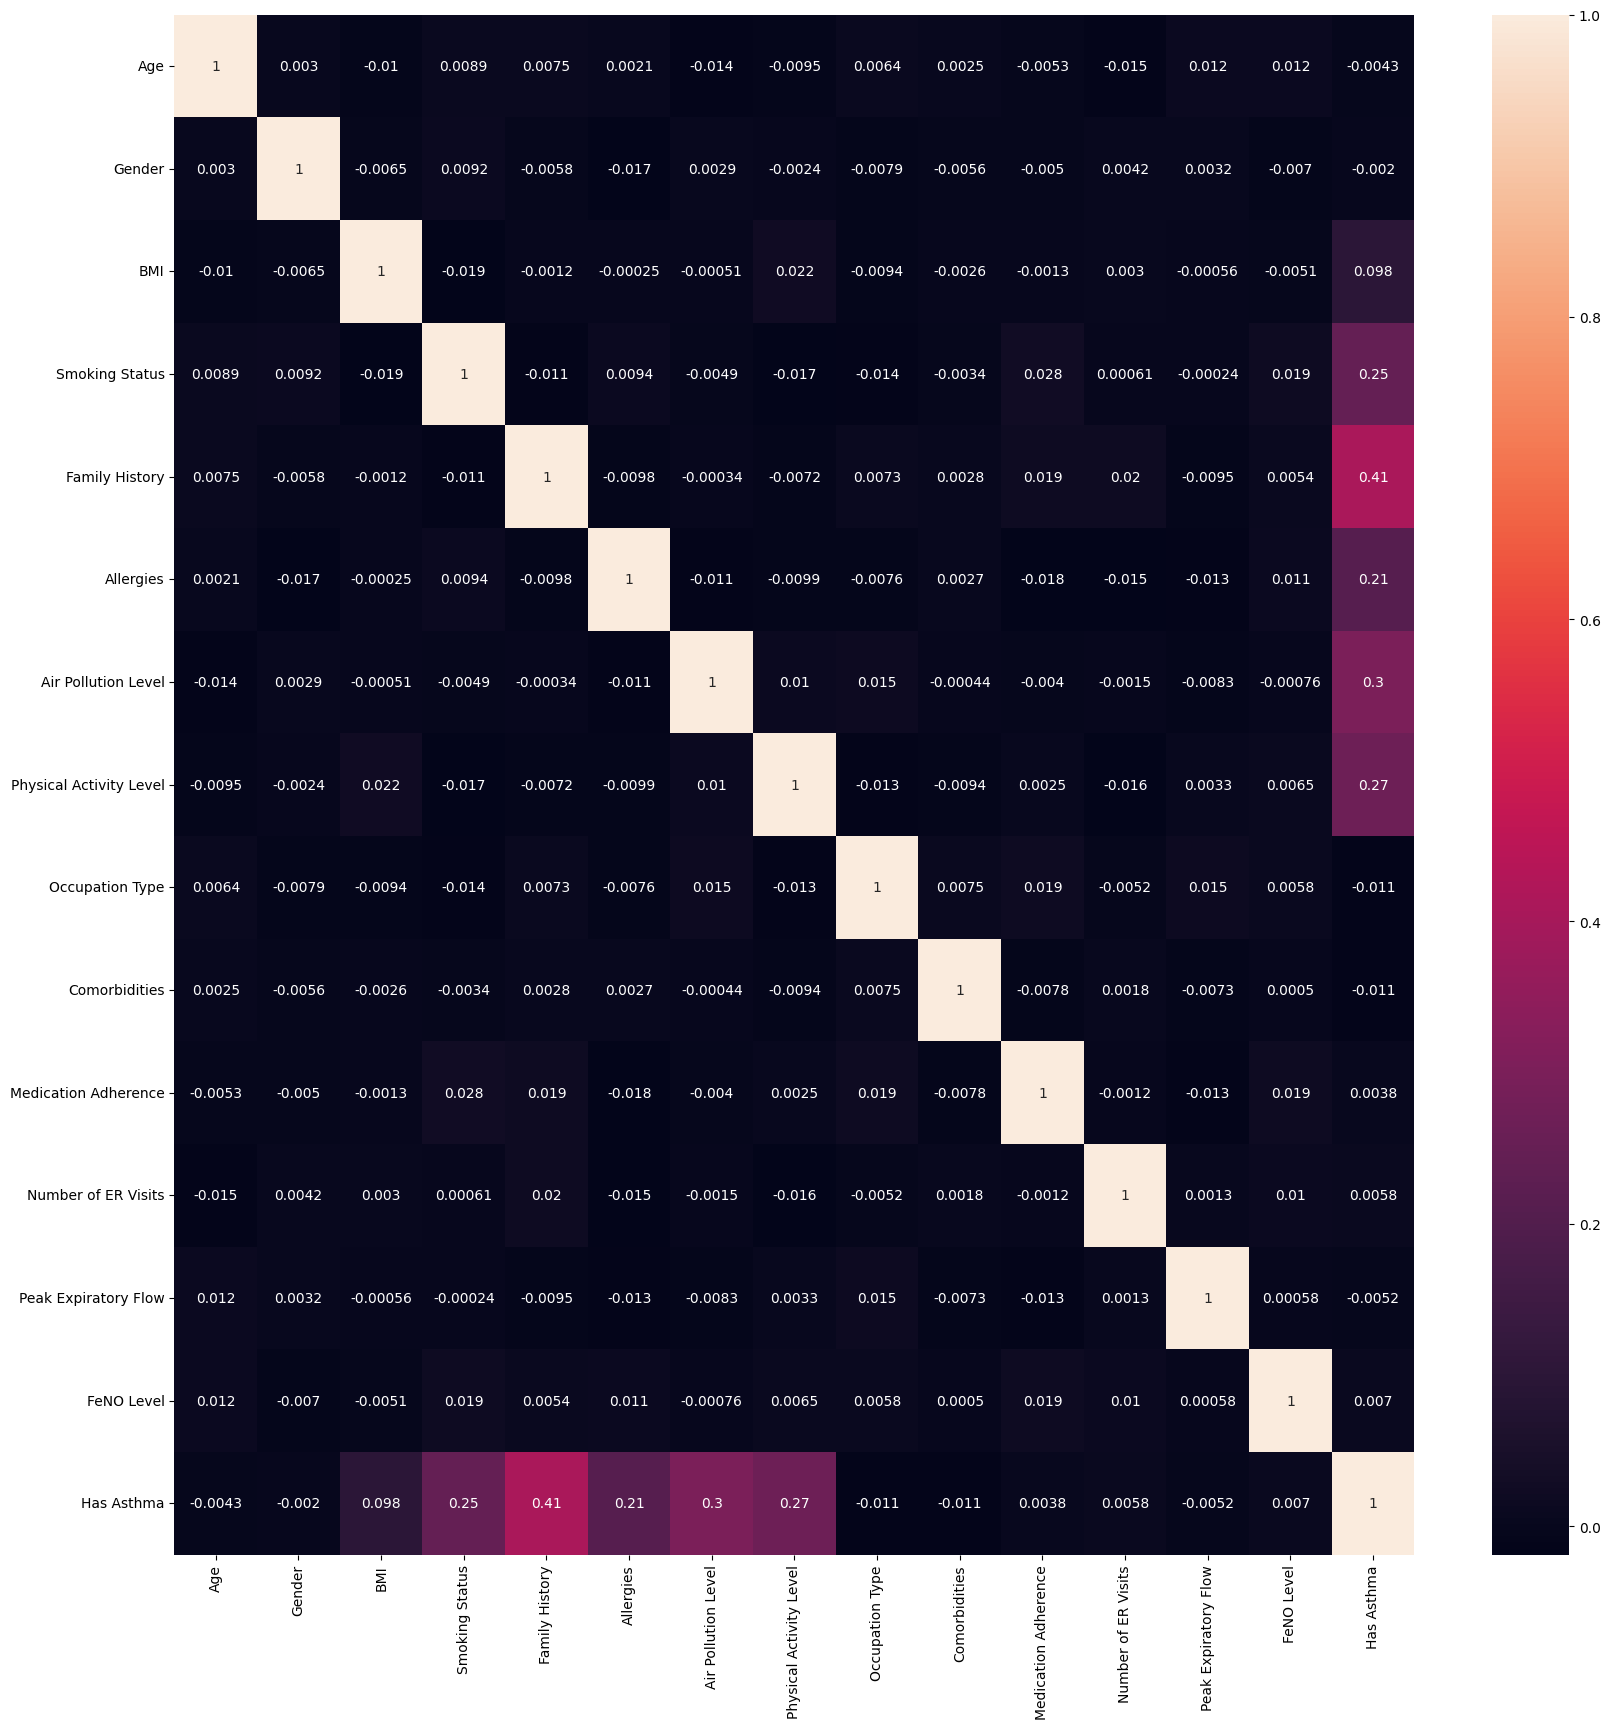

In [14]:
plt.figure(figsize=(20,20))
ax = sns.heatmap(data.corr(),annot = True)
plt.savefig('coorelation-coefficients.jpg')
plt.show()

In [15]:
x = data.drop(columns = 'Has Asthma')
y = data['Has Asthma']

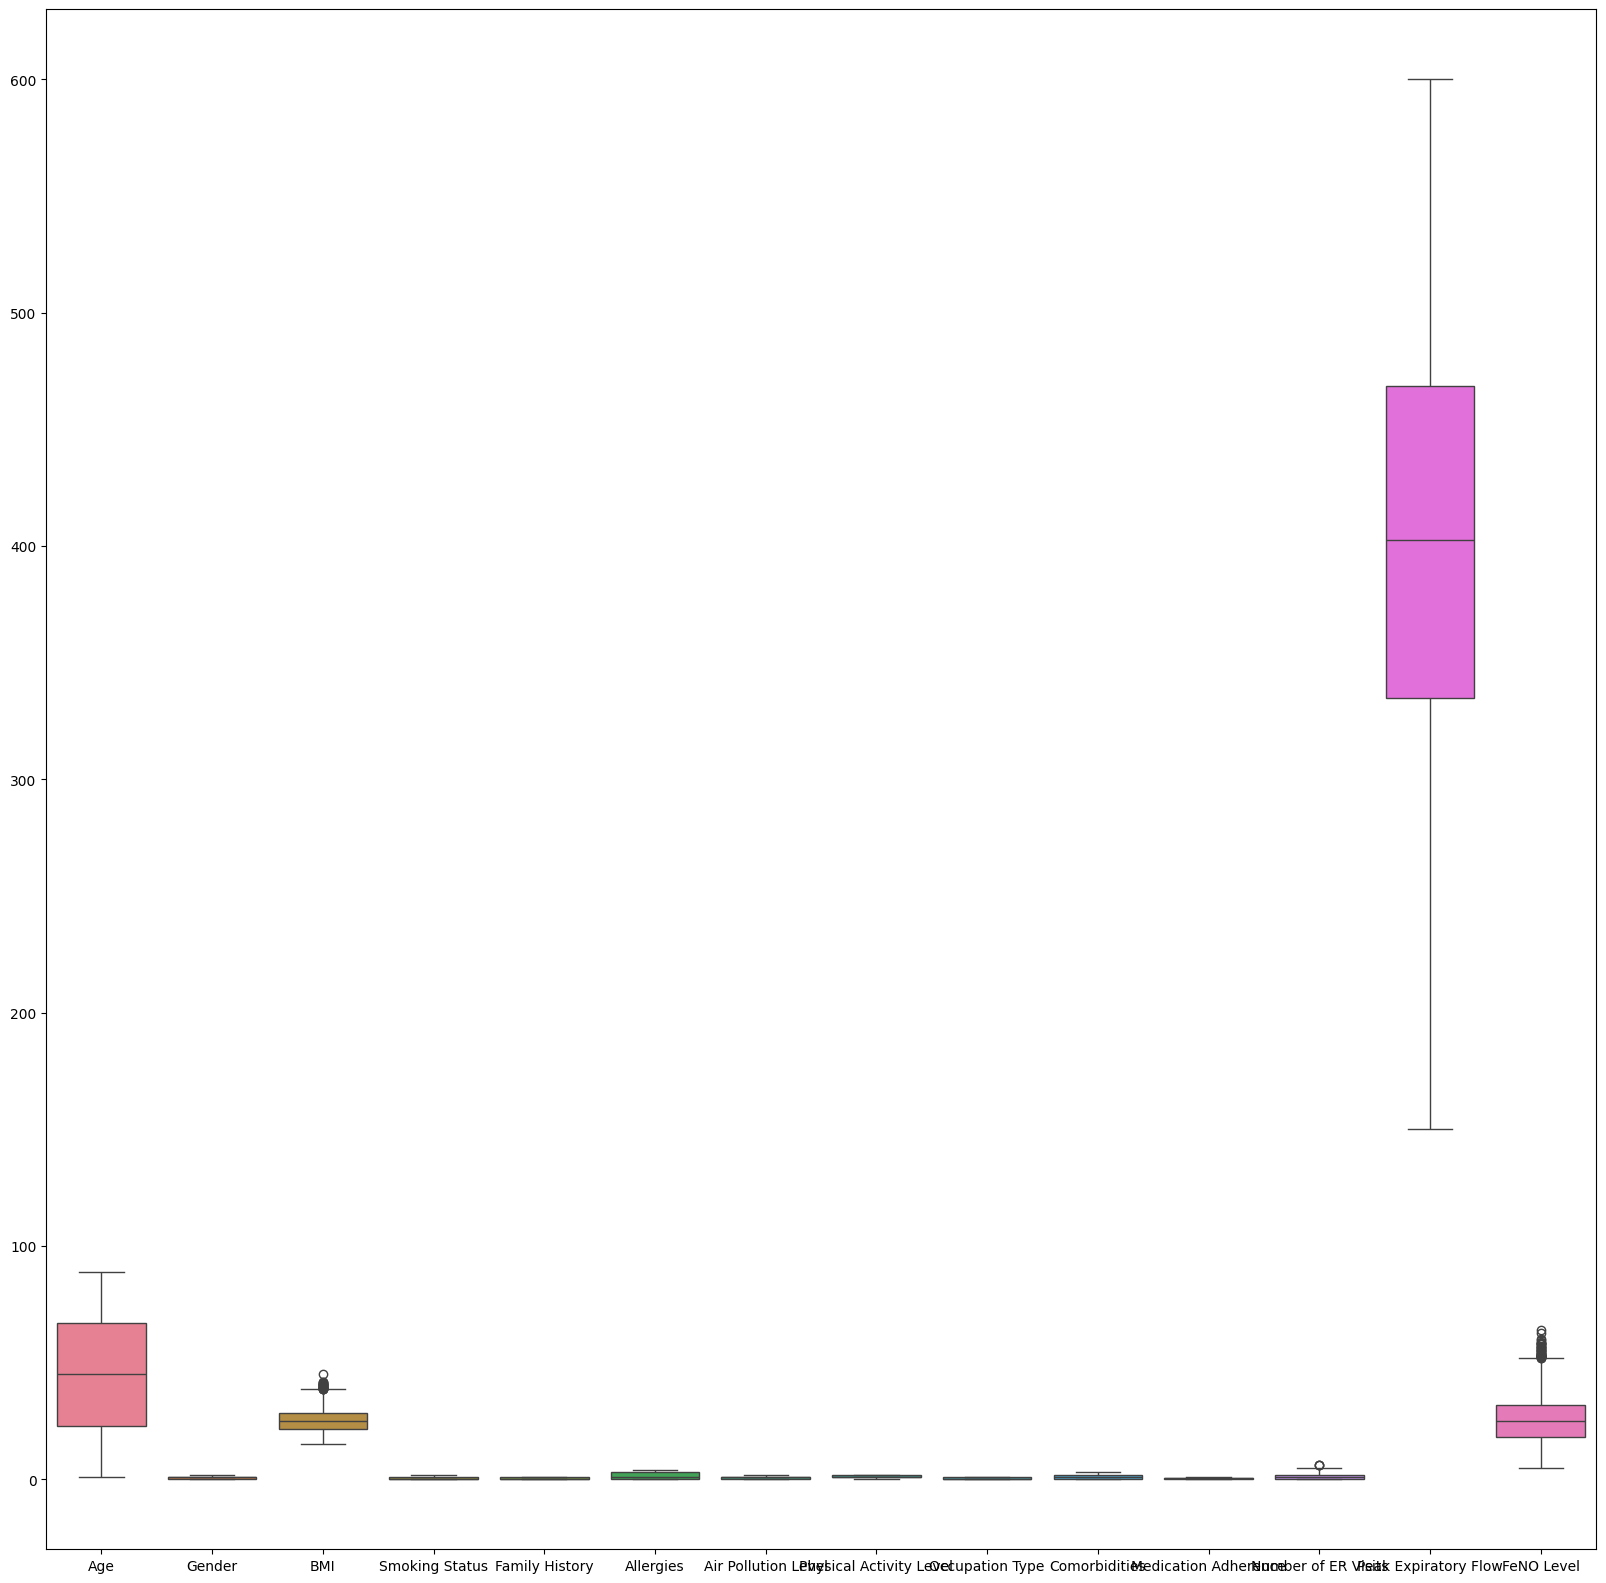

In [16]:
fig, ax = plt.subplots(figsize = (20,20))
sns.boxplot(data=x,ax=ax)
plt.show()

In [17]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'BMI', 'Smoking Status',
       'Family History', 'Allergies', 'Air Pollution Level',
       'Physical Activity Level', 'Occupation Type', 'Comorbidities',
       'Medication Adherence', 'Number of ER Visits', 'Peak Expiratory Flow',
       'FeNO Level', 'Has Asthma', 'Asthma_Control_Level'],
      dtype='object')

In [18]:
cols =['Age', 'Gender', 'BMI', 'Smoking Status',
       'Family History', 'Allergies', 'Air Pollution Level',
       'Physical Activity Level', 'Occupation Type', 'Comorbidities',
       'Medication Adherence', 'Number of ER Visits', 'Peak Expiratory Flow',
       'FeNO Level']

In [19]:
combined_mask = pd.Series(True, index=x.index)

for col_name in cols:
  if col_name in x.columns and pd.api.types.is_numeric_dtype(x[col_name]):
    Q1 = x[col_name].quantile(0.25)
    Q3 = x[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    col_mask = (x[col_name] >= lower_bound) & \
               (x[col_name] <= upper_bound)

    combined_mask = combined_mask & col_mask
  else:
    pass
x_outlier_detection = x[combined_mask]
y_outlier_detection = y[combined_mask]

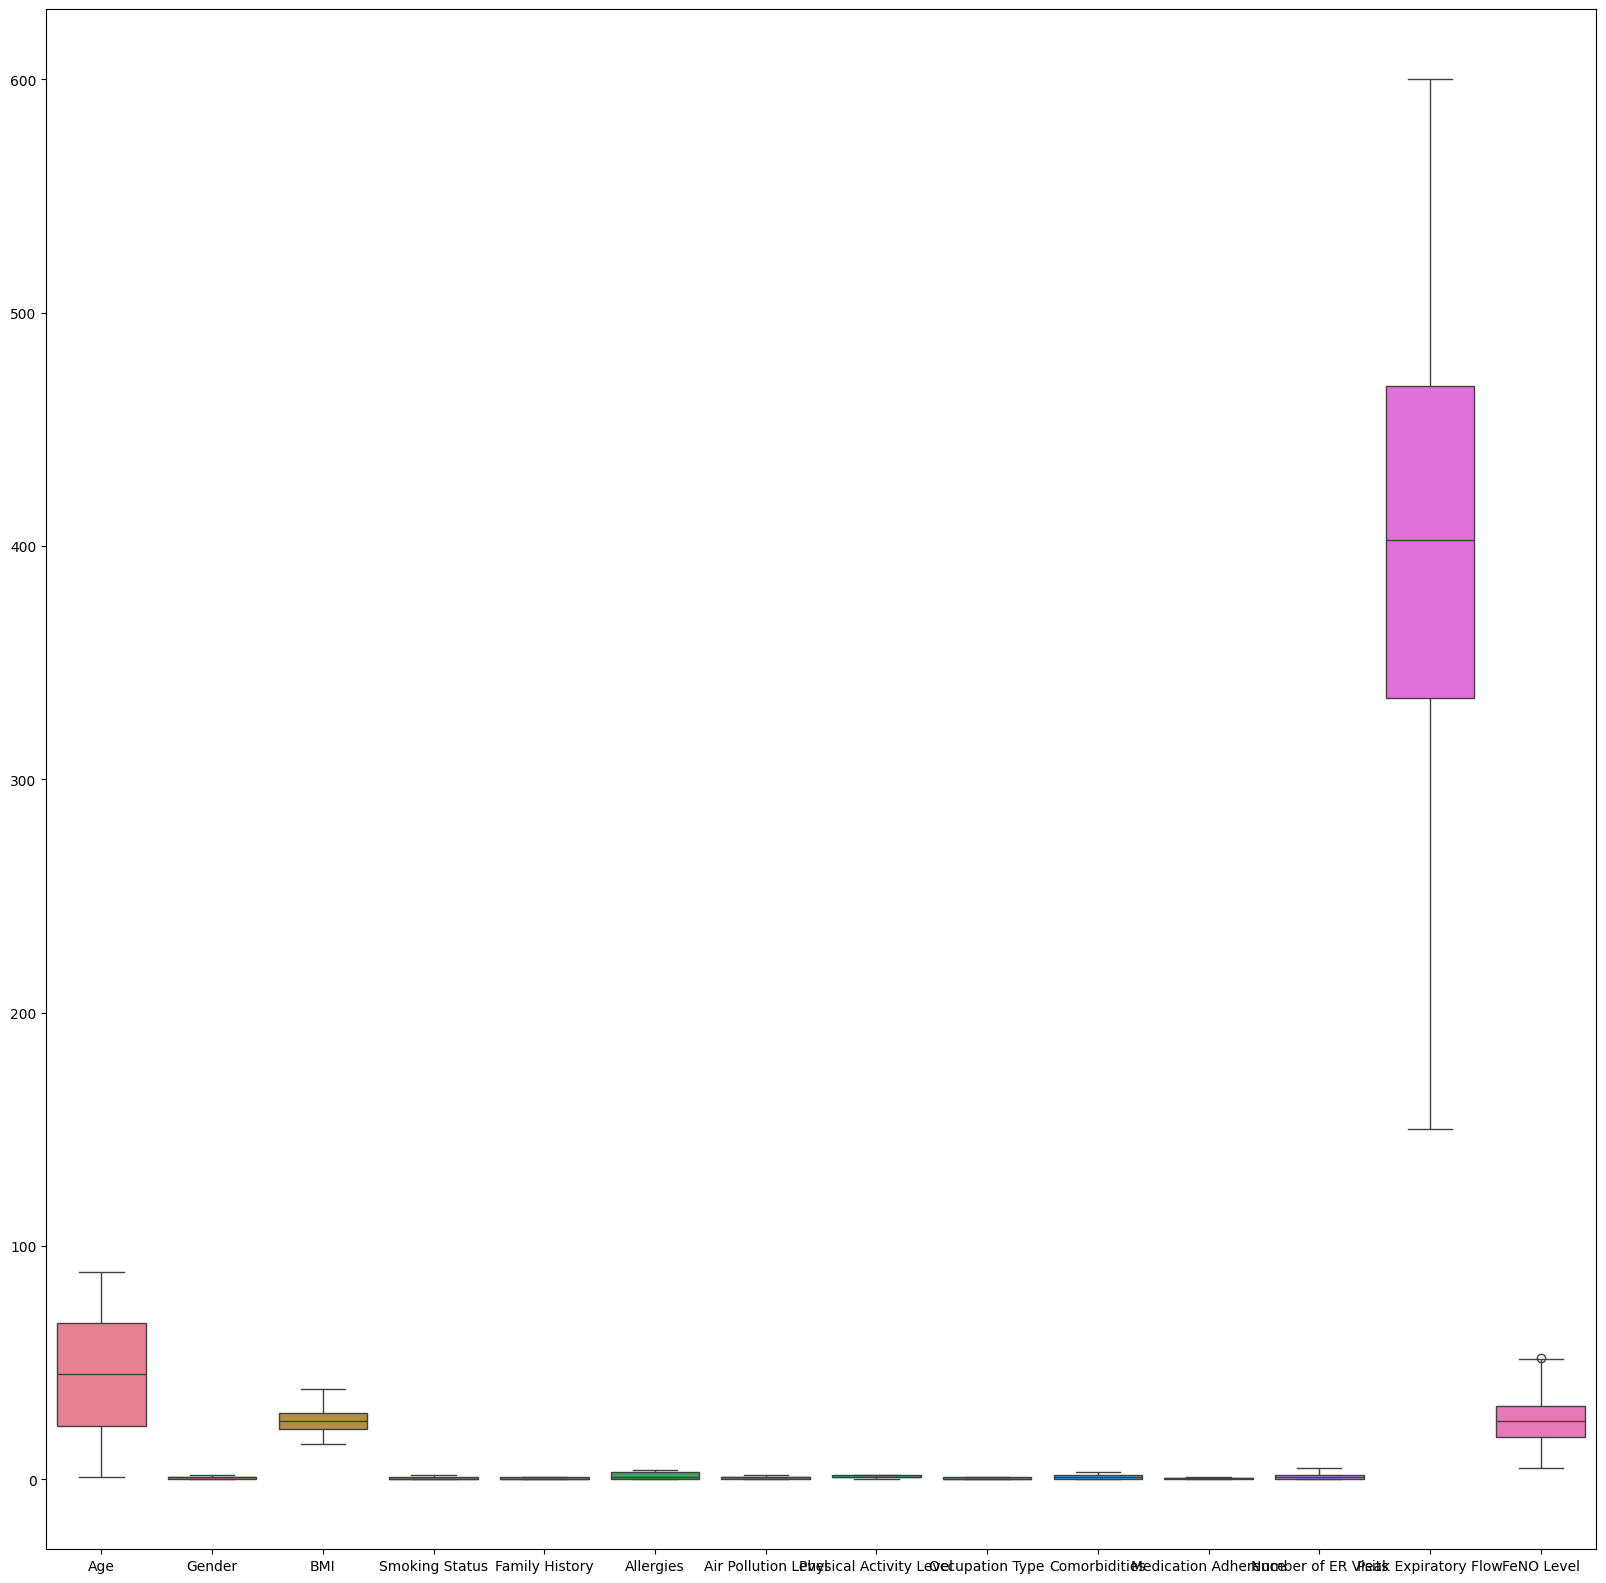

In [20]:
fig, ax = plt.subplots(figsize = (20,20))
sns.boxplot(data=x_outlier_detection,ax=ax)
plt.show()

In [21]:
x_outlier_detection.shape

(9932, 14)

In [22]:
y_outlier_detection.shape

(9932,)

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x_outlier_detection)

In [24]:
x_scaled = pd.DataFrame(X_scaled, columns=cols, index=x_outlier_detection.index)
x_scaled.describe()

,Age,Gender,BMI,Smoking Status,Family History,Allergies,Air Pollution Level,Physical Activity Level,Occupation Type,Comorbidities,Medication Adherence,Number of ER Visits,Peak Expiratory Flow,FeNO Level
count,9.932000e+03,9.932000e+03,9.932000e+03,9.932000e+03,9.932000e+03,9.932000e+03,9.932000e+03,9.932000e+03,9.932000e+03,9.932000e+03,9.932000e+03,9.932000e+03,9.932000e+03,9.932000e+03
mean,9.514920e-17,-5.937882e-17,-4.217327e-16,6.295586e-17,-4.149364e-17,2.289304e-17,1.788519e-17,-5.759030e-17,2.718549e-17,-4.793230e-17,-3.290875e-17,1.087419e-16,7.225616e-17,-3.040482e-17
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00
min,-1.713286e+00,-9.834115e-01,-2.075764e+00,-7.327293e-01,-6.605285e-01,-1.155226e+00,-1.289105e+00,-1.596357e+00,-6.493847e-01,-8.668719e-01,-2.213611e+00,-9.967889e-01,-2.572561e+00,-2.067555e+00
25%,-8.556812e-01,-9.834115e-01,-7.076689e-01,-7.327293e-01,-6.605285e-01,-1.155226e+00,-1.289105e+00,-2.689108e-01,-6.493847e-01,-8.668719e-01,-7.907166e-01,-9.967889e-01,-6.770299e-01,-7.005712e-01
50%,1.923197e-03,7.676181e-01,-2.892670e-03,-7.327293e-01,-6.605285e-01,-4.165121e-01,1.243848e-01,-2.689108e-01,-6.493847e-01,9.382568e-02,9.661340e-03,-1.405043e-02,1.738282e-02,-6.723228e-03
75%,8.595276e-01,7.676181e-01,7.018835e-01,6.323931e-01,1.513939e+00,1.060916e+00,1.243848e-01,1.058535e+00,1.539919e+00,1.054523e+00,7.655739e-01,9.686880e-01,6.943583e-01,6.871247e-01
max,1.717132e+00,2.518648e+00,2.795483e+00,1.997516e+00,1.513939e+00,1.799630e+00,1.537874e+00,1.058535e+00,1.539919e+00,2.015221e+00,2.188468e+00,3.916903e+00,2.043181e+00,2.779024e+00


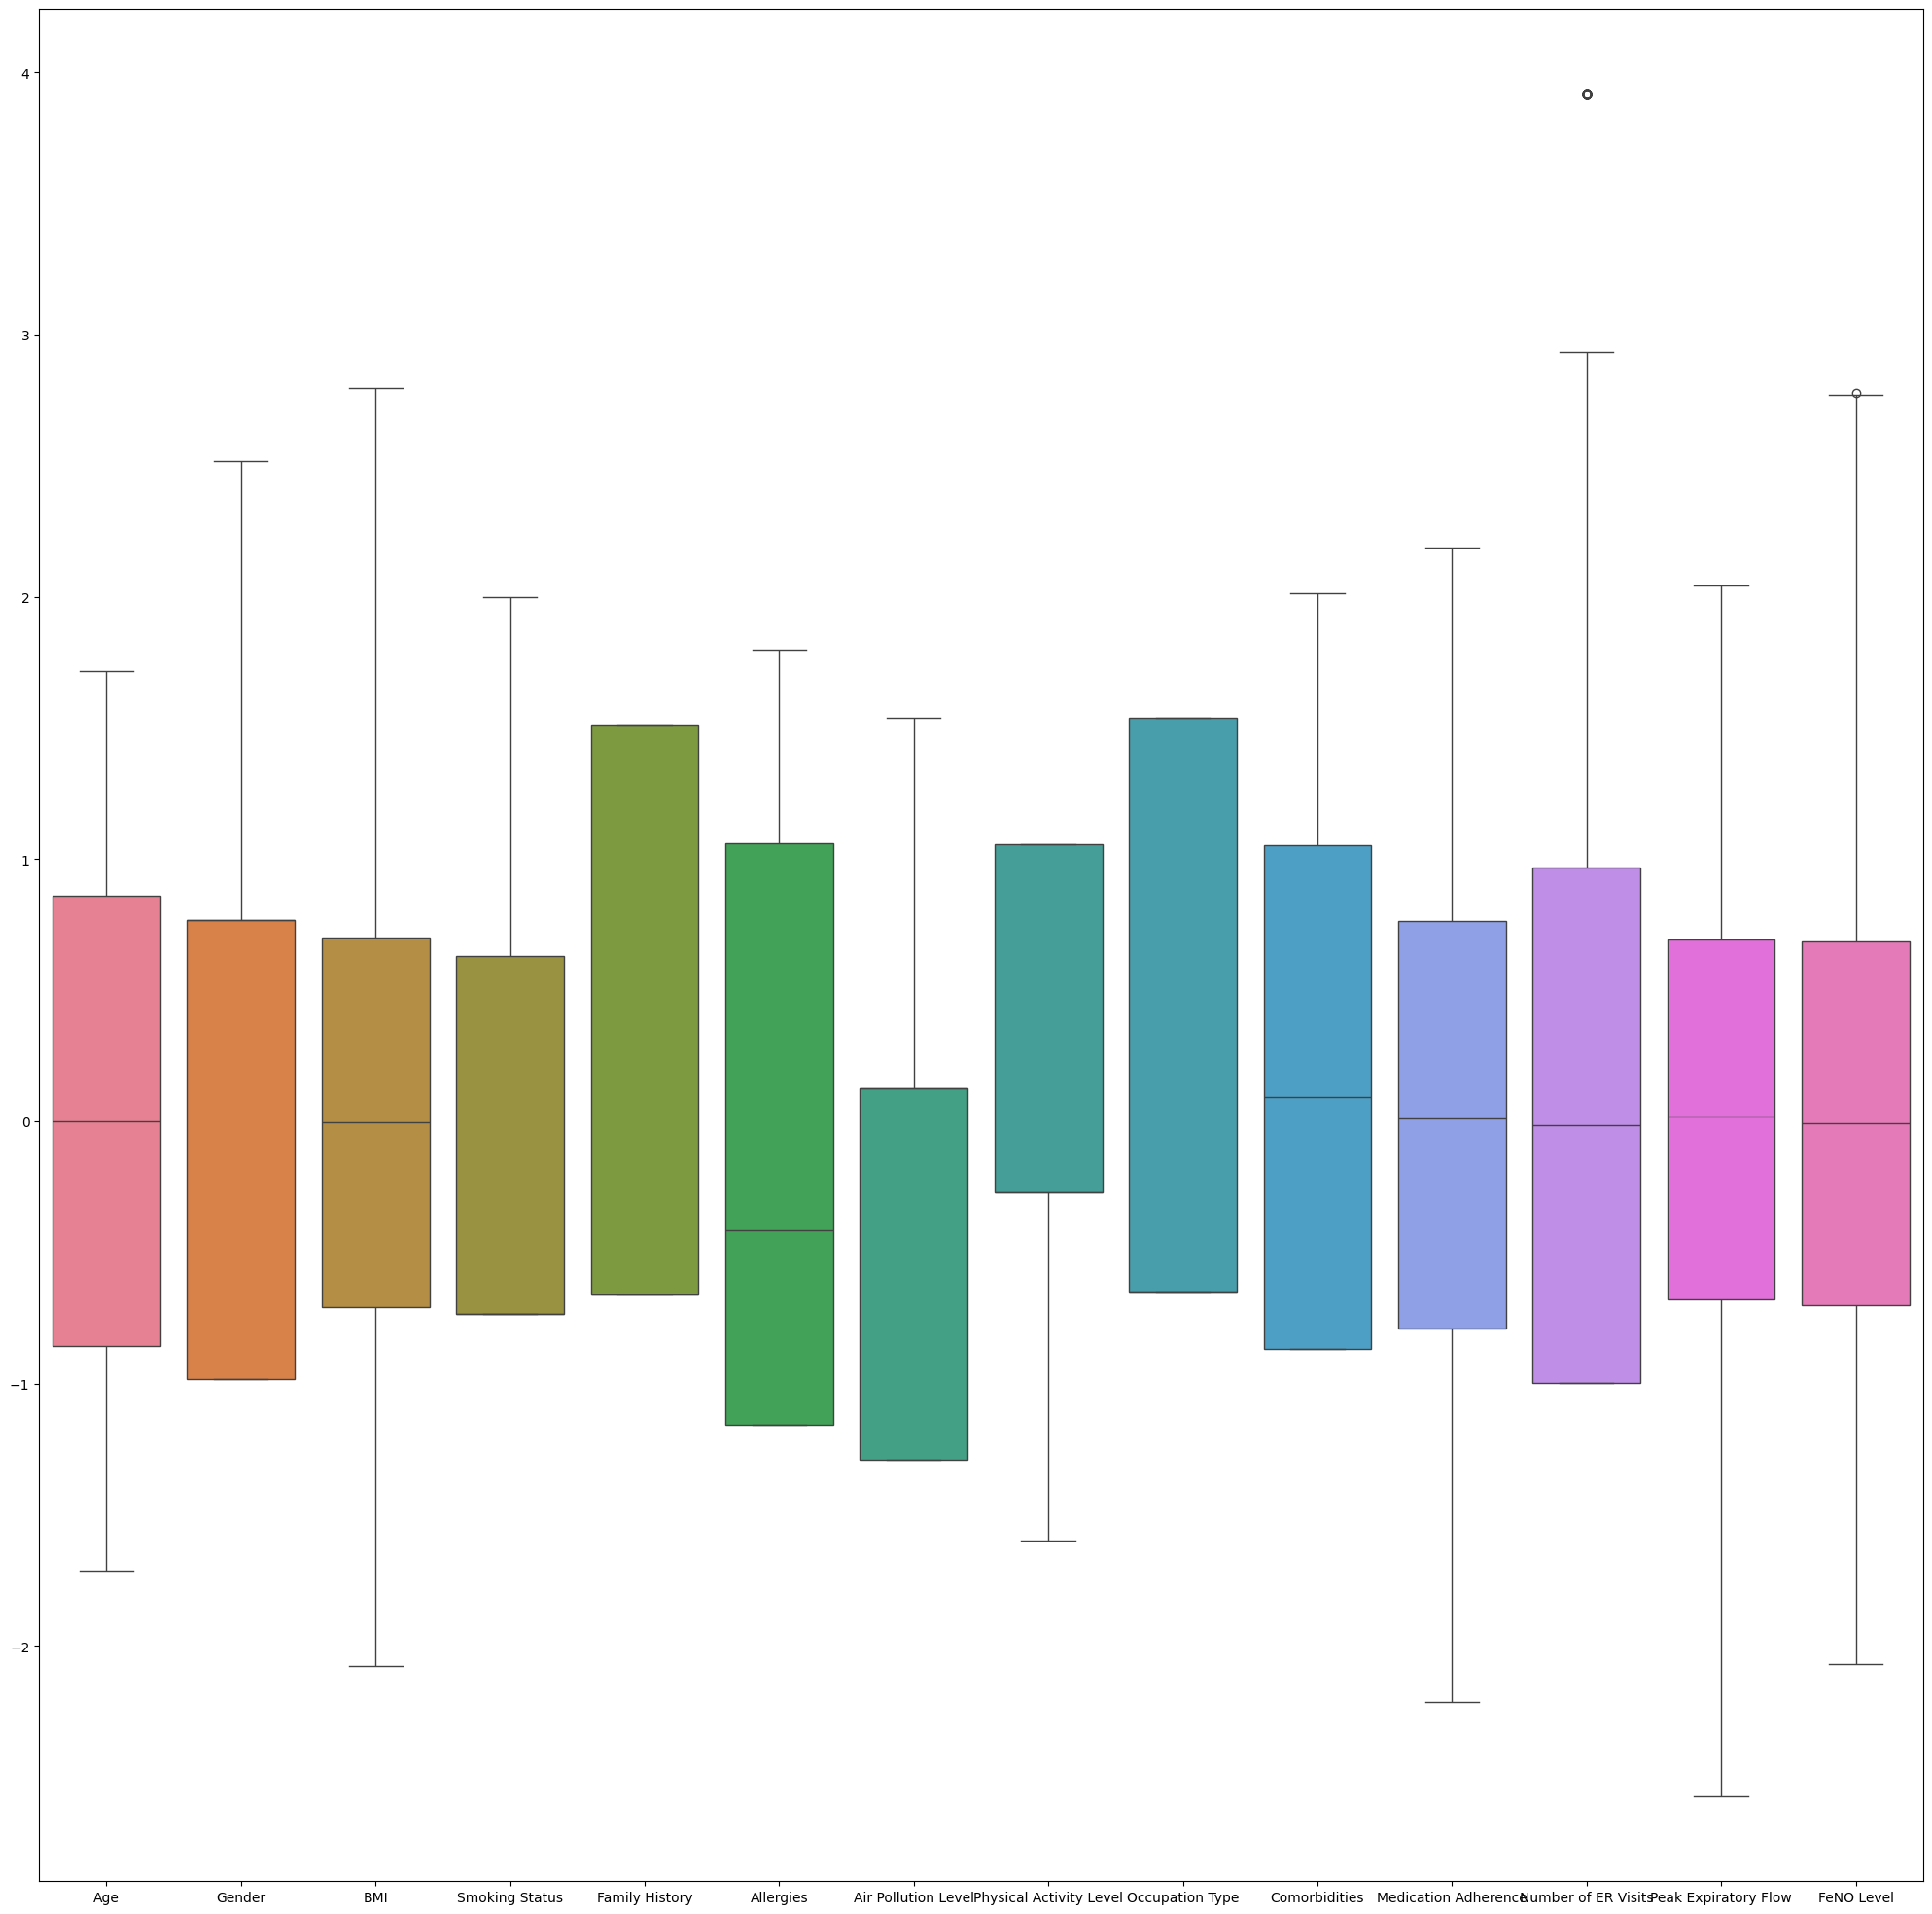

In [25]:
fig, ax = plt.subplots(figsize = (25,25))
sns.boxplot(data=x_scaled,ax=ax)
plt.show()

In [26]:
y_outlier_detection.value_counts()

,count
Has Asthma,
0,7526
1,2406


In [27]:
x_scaled.shape

(9932, 14)

In [28]:
y_outlier_detection.shape

(9932,)

In [29]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_scaled,y_outlier_detection,test_size = 0.3,random_state = 42)

In [30]:
x_train.shape

(6952, 14)

In [31]:
x_test.shape

(2980, 14)

In [32]:
y_train.value_counts()

,count
Has Asthma,
0,5263
1,1689


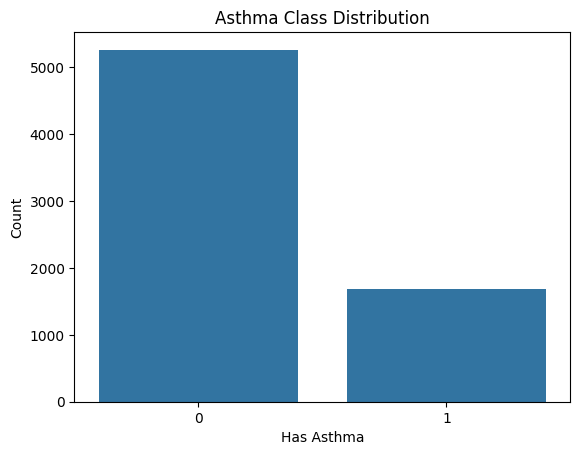

In [33]:
sns.countplot(x=y_train)

plt.title("Asthma Class Distribution")
plt.xlabel("Has Asthma")
plt.ylabel("Count")
plt.show()

In [34]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

print("\nResampled class distribution")
print(pd.Series(y_train_resampled).value_counts())


Resampled class distribution
Has Asthma
0    5263
1    5263
Name: count, dtype: int64


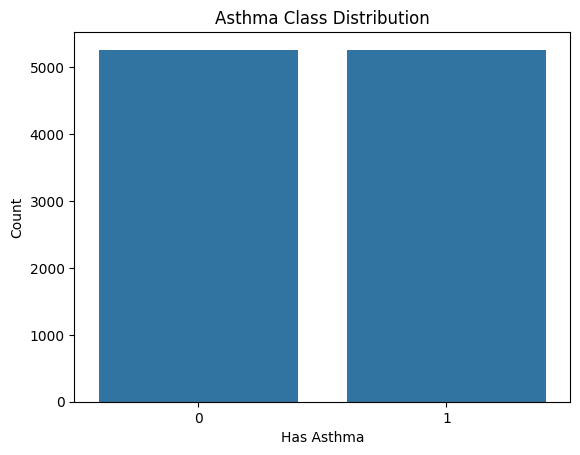

In [35]:
sns.countplot(x=y_train_resampled)

plt.title("Asthma Class Distribution")
plt.xlabel("Has Asthma")
plt.ylabel("Count")
plt.show()

In [36]:
# Model comparison before selecting SVM

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "Gradient Boosting": GradientBoostingClassifier()
}

print("Model Accuracy Comparison\n")

results = {}

for name, model in models.items():

    model.fit(x_train_resampled, y_train_resampled)
    predictions = model.predict(x_test)

    accuracy = accuracy_score(y_test, predictions)
    results[name] = accuracy

    print(f"{name}: {accuracy:.4f}")

# Optional: show best model
best_model = max(results, key=results.get)
print("\nBest performing model:", best_model)

Model Accuracy Comparison

Logistic Regression: 0.8574
Decision Tree: 0.9987
Random Forest: 0.9980
Naive Bayes: 0.8611
KNN: 0.8628


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:01:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost: 0.9993
Gradient Boosting: 0.9990

Best performing model: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:01:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


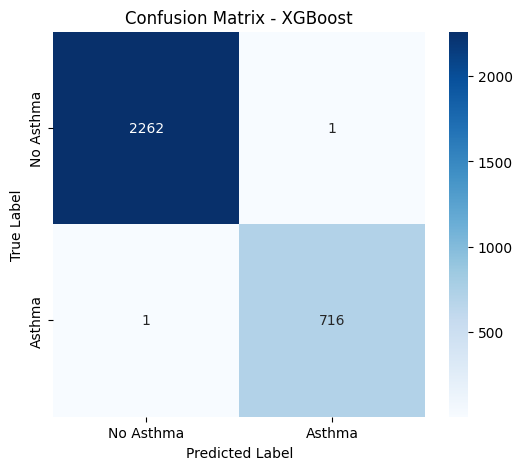

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train XGBoost model
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(x_train_resampled, y_train_resampled)

# Predictions
xgb_pred = xgb_model.predict(x_test)

# Confusion Matrix
cm = confusion_matrix(y_test, xgb_pred)

# Plot Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Asthma','Asthma'],
            yticklabels=['No Asthma','Asthma'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost")

plt.show()

In [38]:
from sklearn.svm import SVC
svm_classifier = SVC()
svm_classifier.fit(x_train_resampled,y_train_resampled)

SVC()

In [39]:
svm_1 = svm_classifier.predict(x_test)
print(svm_1)

[1 0 0 ... 0 0 1]


In [40]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,svm_1)

0.9778523489932885

In [41]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,svm_1)

array([[2222,   41],
       [  25,  692]])

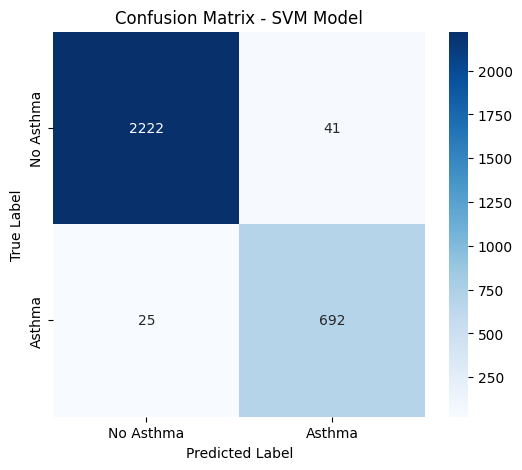

In [42]:
cm = confusion_matrix(y_test, svm_1)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Asthma','Asthma'],
            yticklabels=['No Asthma','Asthma'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM Model")

plt.show()

In [43]:
from sklearn.metrics import classification_report
print(classification_report(y_test,svm_1))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2263
           1       0.94      0.97      0.95       717

    accuracy                           0.98      2980
   macro avg       0.97      0.97      0.97      2980
weighted avg       0.98      0.98      0.98      2980



In [44]:
from sklearn.svm import SVC
svm_classifier_op = SVC(C=10, degree=2,gamma='auto')
svm_classifier_op.fit(x_train, y_train)
svm = svm_classifier_op.predict(x_test)

In [45]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,svm)

0.9828859060402685

In [46]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,svm)

array([[2236,   27],
       [  24,  693]])

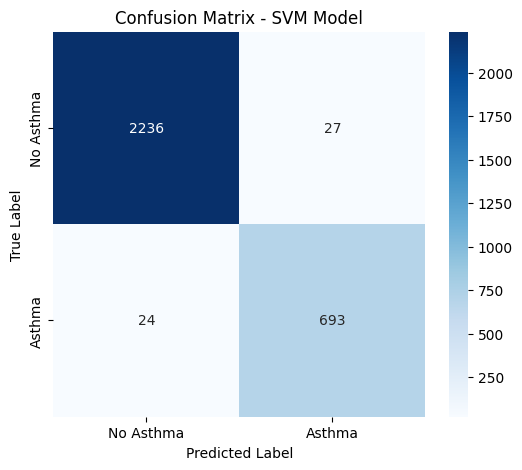

In [47]:
cm = confusion_matrix(y_test, svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Asthma','Asthma'],
            yticklabels=['No Asthma','Asthma'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM Model")

plt.show()

In [48]:
from sklearn.metrics import classification_report
print(classification_report(y_test,svm))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2263
           1       0.96      0.97      0.96       717

    accuracy                           0.98      2980
   macro avg       0.98      0.98      0.98      2980
weighted avg       0.98      0.98      0.98      2980



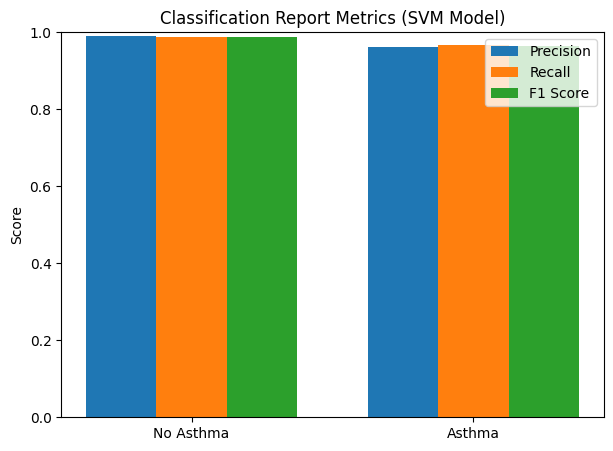

In [49]:
report = classification_report(y_test, svm, output_dict=True)

# Convert to dataframe
df = pd.DataFrame(report).transpose()

# Select only class metrics
metrics = df.loc[['0','1'], ['precision','recall','f1-score']]

# Bar positions
x = np.arange(len(metrics.index))
width = 0.25

plt.figure(figsize=(7,5))

plt.bar(x - width, metrics['precision'], width, label='Precision')
plt.bar(x, metrics['recall'], width, label='Recall')
plt.bar(x + width, metrics['f1-score'], width, label='F1 Score')

plt.xticks(x, ['No Asthma','Asthma'])
plt.ylabel("Score")
plt.title("Classification Report Metrics (SVM Model)")
plt.ylim(0,1)

plt.legend()
plt.show()

In [50]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 26.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=677e0b376592e95a3d298b51c32a717acad9bbab42ce54ef4bbd121852a13296
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [51]:
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    print("SHAP not installed. Install with: pip install shap")
    SHAP_AVAILABLE = False
try:
    import lime
    from lime.lime_tabular import LimeTabularExplainer
    LIME_AVAILABLE = True
except ImportError:
    print("LIME not installed. Install with: pip install lime")
    LIME_AVAILABLE = False



In [52]:
from sklearn.model_selection import train_test_split
x_train_new,x_test_new,y_train_new,y_test_new = train_test_split(x_scaled,y_outlier_detection,test_size = 0.02,random_state = 42)

In [53]:
y_train_new.shape

(9733,)

In [54]:
from sklearn.svm import SVC


svm_classifier_op = SVC(kernel="rbf",C=10,degree=2,probability=True,random_state=42)
svm_classifier_op.fit(x_train_new, y_train_new)

background = shap.sample(x_train_new, 100)

explainer = shap.KernelExplainer(svm_classifier_op.predict_proba, background)
shap_values = explainer.shap_values(x_test_new)

  0%|          | 0/199 [00:00<?, ?it/s]

In [55]:
x_test_sample = x_test_new.iloc[:50]

shap_values = explainer.shap_values(x_test_sample)

  0%|          | 0/50 [00:00<?, ?it/s]

In [56]:
shap.initjs()

index = 0
features_array = x_test_sample.iloc[index].values

feature_names_list = x_test_sample.columns.tolist()

shap.force_plot(
    explainer.expected_value[1],
    shap_values[index, :, 1],
    features_array,
    feature_names=feature_names_list
)

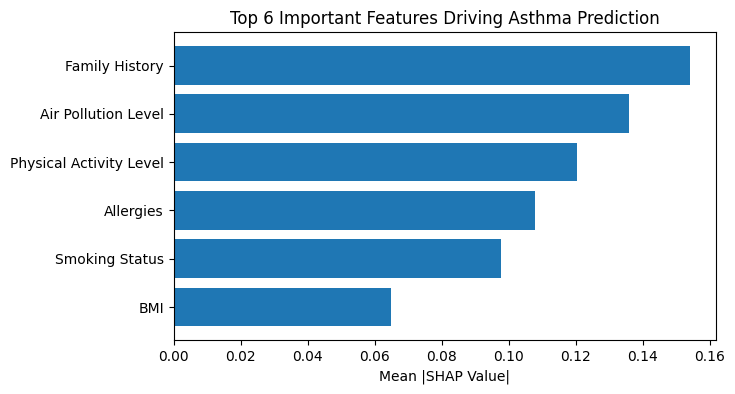

In [57]:
shap_class1 = shap_values[:, :, 1]
shap_importance = np.abs(shap_class1).mean(axis=0)

feature_importance = pd.DataFrame({
    "feature": x_test_sample.columns,
    "importance": shap_importance
})

top6 = feature_importance.sort_values(by="importance", ascending=False).head(6)

plt.figure(figsize=(7,4))
plt.barh(top6["feature"], top6["importance"])
plt.xlabel("Mean |SHAP Value|")
plt.title("Top 6 Important Features Driving Asthma Prediction")
plt.gca().invert_yaxis()

plt.show()

In [58]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(x_train_new),
    feature_names=cols,
    class_names=["Class 0", "Class 1"],
    mode="classification"
)

In [59]:
data_to_explain = x_test_new.iloc[0].values

exp = lime_explainer.explain_instance(
    data_row=data_to_explain,
    predict_fn=svm_classifier_op.predict_proba,
    num_features=len(cols)
)

exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


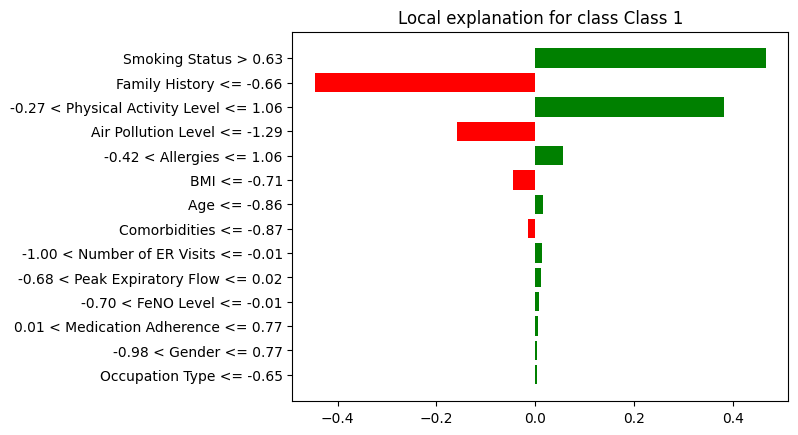

In [60]:
fig = exp.as_pyplot_figure()
plt.show()

In [61]:
pip install shap mistralai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.3/509.3 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.3/160.3 kB 20.4 MB/s eta 0:00:00


In [62]:
def extract_top_features(shap_values_for_instance_class, X_instance_series, cols, top_k=6):
    contributions = list(zip(
        cols,
        shap_values_for_instance_class,
        X_instance_series.values
    ))

    contributions = sorted(
        contributions,
        key=lambda x: abs(x[1]),
        reverse=True
    )[:top_k]

    return contributions

In [63]:
feature_names_list

['Age',
 'Gender',
 'BMI',
 'Smoking Status',
 'Family History',
 'Allergies',
 'Air Pollution Level',
 'Physical Activity Level',
 'Occupation Type',
 'Comorbidities',
 'Medication Adherence',
 'Number of ER Visits',
 'Peak Expiratory Flow',
 'FeNO Level']

In [64]:
top_features = extract_top_features(
    shap_values[0, :, 1],
    x_test_new.iloc[0],
    feature_names_list
)

In [65]:
def build_explanation_context(prediction, top_features):
    explanation = f"The model predicted: {prediction}\n\n"
    explanation += "Key factors influencing this decision:\n"

    for name, shap_val, actual_val in top_features:
        direction = "increased risk" if shap_val > 0 else "reduced risk"
        explanation += (
            f"- {name} = {actual_val} "
            f"({direction}, impact score: {round(shap_val, 3)})\n"
        )

    return explanation


In [66]:
prediction = svm_classifier_op.predict(x_test_new.iloc[[0]])[0]
context = build_explanation_context(prediction, top_features)

In [67]:
from mistralai import Mistral

client = Mistral(api_key="NXy7GTO76W7h5BERUV0ehOEdN2tKDnIw")

In [68]:
def generate_llm_explanation(context):
    prompt = f"""
You are a clinical decision-support AI system.
Your role is to explain a health risk prediction clearly and safely.

Follow these rules STRICTLY:
- Do NOT mention machine learning, SHAP, SVM, models, or algorithms
- Do NOT make medical diagnoses
- Do NOT give treatment instructions
- Use simple, patient-friendly language
- Base explanations ONLY on the provided information
- Be neutral, factual, and cautious

Explain the prediction in the following STRUCTURE:

1. Key Factors
- List the most important patient factors that influenced the risk.
- Explicitly refer to patient characteristics such as age, smoking history, or body weight when relevant.

2. Why These Factors Matter
- Explain how the top 4 factor affects asthma risk using cause–effect reasoning.

3. What This Means
- Explain what the predicted risk level indicates.
- Clarify this is a risk estimate, not a diagnosis.

4. General Health Considerations
- Mention general, non-prescriptive health considerations.

Patient Information and Prediction:

Feature explanations:
{FEATURE_DEFINITIONS}

Prediction details:
{context}

Now generate the explanation.
"""

    response = client.chat.complete(
        model="mistral-large-latest",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2
    )

    return response.choices[0].message.content


In [84]:
FEATURE_DEFINITIONS = """
Age: Older age can affect lung function and asthma control.
Smoking History: Smoking can irritate airways and worsen asthma symptoms.
BMI: Higher body weight can increase breathing difficulty.
Family History: Genetics can influence asthma susceptibility.
"""


In [85]:
TOP_FEATURES = [name for name, _, _ in top_features]
TOP_FEATURES

['Smoking Status',
 'Physical Activity Level',
 'Allergies',
 'Family History',
 'Air Pollution Level',
 'BMI']

In [86]:
FEATURE_ALIASES = {
    "Age": ["age", "older", "younger"],
    "BMI": ["body weight", "weight", "body mass"],
    "Smoking History": ["smoking", "smoker", "tobacco",'smoking history'],
    "Physical Activity Level": ["physical activity", "activity level","Physical activity level"],
    "Family History": ["family history", "family member", "family member history","Family history of asthma"]
}


In [87]:
def check_explanation_fidelity(llm_text, top_features, aliases):
    llm_text = llm_text.lower()
    mentioned = 0

    for feature, _, _ in top_features:
        names = [feature.lower()] + aliases.get(feature, [])
        if any(n in llm_text for n in names):
            mentioned += 1

    return mentioned / len(top_features)


In [88]:
final_explanation = generate_llm_explanation(context)
print(final_explanation)

**Understanding Your Asthma Risk Estimate**

1. **Key Factors**
The following patient characteristics had the strongest influence on your estimated asthma risk:
- Current or past smoking
- Level of physical activity
- Presence of allergies
- Family history of asthma (which slightly lowered the risk)
- Air pollution exposure (which slightly lowered the risk)
- Body weight (which slightly lowered the risk)

2. **Why These Factors Matter**
- **Smoking**: Smoking irritates the airways, making them more sensitive and prone to inflammation. Over time, this can increase the likelihood of breathing difficulties and asthma-like symptoms.
- **Physical Activity Level**: While regular activity is generally healthy, lower physical activity levels may be linked to weaker lung function or other health conditions that could contribute to breathing challenges.
- **Allergies**: Allergies can trigger inflammation in the airways, making them more reactive and increasing the chance of asthma symptoms.
- **

In [109]:
NUM_RUNS = 7

explanations = [generate_llm_explanation(context) for _ in range(NUM_RUNS)]


In [110]:
def compute_fidelity(explanation, top_features):

    explanation = explanation.lower()

    feature_names = [name.lower() for name, _, _ in top_features]

    mentioned = 0

    for feature in feature_names:
        if feature in explanation:
            mentioned += 1

    fidelity = mentioned / len(feature_names)

    return fidelity

In [111]:
fidelity_scores = []

for exp in explanations:
    score = compute_fidelity(exp, top_features)
    fidelity_scores.append(score)

average_fidelity = sum(fidelity_scores) / len(fidelity_scores)

print("Fidelity Scores:", fidelity_scores)
print("Average Fidelity:", round(average_fidelity, 3))

Fidelity Scores: [0.5, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.5, 0.6666666666666666, 0.6666666666666666]
Average Fidelity: 0.619


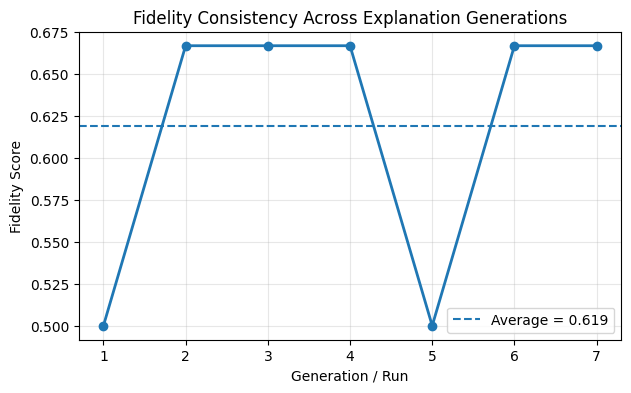

In [112]:
runs = np.arange(1, len(fidelity_scores) + 1)

avg_fidelity = np.mean(fidelity_scores)

plt.figure(figsize=(7,4))

plt.plot(runs, fidelity_scores, marker='o', linewidth=2)
plt.axhline(avg_fidelity, linestyle='--', label=f'Average = {avg_fidelity:.3f}')

plt.xticks(runs)
plt.xlabel("Generation / Run")
plt.ylabel("Fidelity Score")
plt.title("Fidelity Consistency Across Explanation Generations")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [113]:
def extract_mentioned_features(explanation, top_features):

    explanation = explanation.lower()

    mentioned = set()

    for feature, _, _ in top_features:
        if feature.lower() in explanation:
            mentioned.add(feature)

    return mentioned

In [114]:
import math
from collections import Counter

def compute_entropy(feature_sets):

    total_runs = len(feature_sets)

    counter = Counter()

    for fs in feature_sets:
        for f in fs:
            counter[f] += 1

    entropy = 0

    for count in counter.values():
        p = count / total_runs
        entropy -= p * math.log2(p)

    return entropy

In [115]:
feature_sets = [
    extract_mentioned_features(exp, top_features)
    for exp in explanations
]

entropy_score = compute_entropy(feature_sets)

print("Entropy Score:", round(entropy_score, 3))

Entropy Score: 0.347


In [116]:
print("\n------ Explanation Reliability Evaluation ------")

print("Average Fidelity:", round(average_fidelity,3))
print("Entropy:", round(entropy_score,3))

print("\nInterpretation:")

if average_fidelity >= 0.7:
    print("High alignment between SHAP features and LLM explanation.")
elif average_fidelity >= 0.5:
    print("Moderate alignment between SHAP features and explanation.")
else:
    print("Low alignment between SHAP features and explanation.")

if entropy_score <= 0.3:
    print("Explanation is highly stable across runs.")
elif entropy_score <= 0.6:
    print("Explanation shows moderate variability.")
else:
    print("Explanation is unstable across runs.")


------ Explanation Reliability Evaluation ------
Average Fidelity: 0.619
Entropy: 0.347

Interpretation:
Moderate alignment between SHAP features and explanation.
Explanation shows moderate variability.


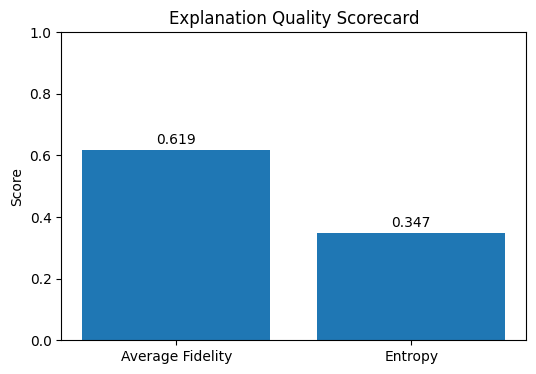

In [117]:
metrics = ["Average Fidelity", "Entropy"]
values = [average_fidelity, entropy_score]

plt.figure(figsize=(6,4))

bars = plt.bar(metrics, values)

plt.ylabel("Score")
plt.title("Explanation Quality Scorecard")

for i, v in enumerate(values):
    plt.text(i, v + 0.02, round(v,3), ha='center')

plt.ylim(0,1)

plt.show()

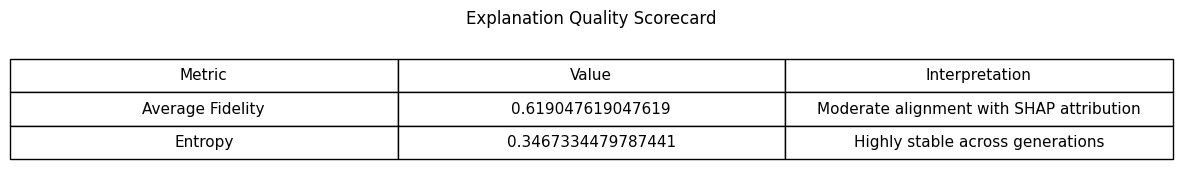

In [118]:
fig, ax = plt.subplots(figsize=(15,2))

ax.axis('off')

table_data = [
    ["Average Fidelity",average_fidelity, "Moderate alignment with SHAP attribution"],
    ["Entropy", entropy_score , "Highly stable across generations"]
]

table = ax.table(
    cellText=table_data,
    colLabels=["Metric", "Value", "Interpretation"],
    loc='center',
    cellLoc='center',   # center align cell text
    colLoc='center'     # center align column headers
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1,2)

plt.title("Explanation Quality Scorecard")

plt.show()

In [119]:
import pickle
pickle.dump(svm_classifier_op,open('Asthma_Model.pkl','wb'))

In [120]:
Asthma_model = pickle.load(open('Asthma_Model.pkl','rb'))
Asthma_model.predict(x_test)

array([1, 0, 0, ..., 0, 0, 1])